In [3]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Problem 1: 

Consider the probability distribution $ p $ defined as:

$$
p = \left[ \frac{X_1^2}{X_1^2 + X_1  + X_2}, \frac{X_1}{X_1^2 + X_1  + X_2}, \frac{X_2}{X_1^2 + X_1  + X_2} \right]
$$

where $ X_1 $ and $ X_2 $ are variables. 

Your task is to find the values of $ X_1 $ and $ X_2 $ that maximize the entropy of the probability distribution $ p $. 

Complete the following function with the code for the optimization. Ensure that the optimization reaches the optimum (2% tolerance for the loss function) within 200 iterations starting at point (2,4).

*NOTE: Use the plot of the evolution of the loss as a function of the iteration number to identify if the optimization has reached a local optimum. You shoul play with different optimizers and parameters to see if the optimum has been reached.*

Embed the code into the following function for testing purposes.
```python 
# Test function
def test_fcn_problem_1(x1, x2, iter)
    # x1, x2 are the initial values of the optimization variables
    # iter is the number of iterations for the optimization
    # Define variables for x and y
   
    x = tf.Variable([x1,x2])
    
    # Define the optimizer (Adam optimizer)
    optimizer = tf.optimizers.Adam(learning_rate=0.01)  
    
    
    # Define the loss function
    def loss_fn():
        resultado = ((x[0]**2/(x[0]**2+x[0]+x[1]))*tf.math.log((x[0]**2/(x[0]**2+x[0]+x[1])))/tf.math.log(tf.constant(2.0))) + 
        ((x[0]/(x[0]**2+x[0]+x[1]))*tf.math.log((x[0]/(x[0]**2+x[0]+x[1])))/tf.math.log(tf.constant(2.0))) +
        ((x[1]/(x[0]**2+x[0]+x[1]))*tf.math.log((x[1]/(x[0]**2+x[0]+x[1])))/tf.math.log(tf.constant(2.0)))
        return resultado
    
    # Store the loss values for plotting
    loss_values = []
    
    # Run optimization for a few iterations
    num_iterations = iter
    for i in range(num_iterations):
        with tf.GradientTape() as tape:
            # Compute the loss
            loss = loss_fn()
            
            # Compute gradients of x and y with respect to the loss
            gradients = tape.gradient(loss, [x]) #Poniendo x da error. Se debe poner [x].!!
                                                 #Hay que tener cuidado con los tipos que se le esta pasando a tape.gradient
        
            # Apply gradients to update x.
            optimizer.apply_gradients(zip(gradients, [x]))
            
            # Store the optimization trajectory
            #tf_trajectory.append(np.array(x.numpy()))
            
            # Store the loss values for the graph
            loss_values.append(loss.numpy())


    # Returns the optimum values x1_opt and x2_opt and the loss
    return x[0], x[1], loss
```

In [375]:
# Test function
def test_fcn_problem_1(x1, x2, iter):
    # x1, x2 are the initial values of the optimization variables
    # iter is the number of iterations for the optimization
    # Define variables for x and y
   
    x = tf.Variable([x1,x2])
    
    # Define the optimizer (Adam optimizer)
    optimizer = tf.optimizers.Adam(learning_rate=0.01)  
    
    
    # Define the loss function
    def loss_fn():
        resultado = ((x[0]**2/(x[0]**2+x[0]+x[1]))*tf.math.log((x[0]**2/(x[0]**2+x[0]+x[1])))/tf.math.log(tf.constant(2.0))) + ((x[0]/(x[0]**2+x[0]+x[1]))*tf.math.log((x[0]/(x[0]**2+x[0]+x[1])))/tf.math.log(tf.constant(2.0))) +((x[1]/(x[0]**2+x[0]+x[1]))*tf.math.log((x[1]/(x[0]**2+x[0]+x[1])))/tf.math.log(tf.constant(2.0)))
        return resultado
    
    # Store the loss values for plotting
    loss_values = []
    
    # Run optimization for a few iterations
    num_iterations = iter
    for i in range(num_iterations):
        with tf.GradientTape() as tape:
            # Compute the loss
            loss = loss_fn()
            
            # Compute gradients of x and y with respect to the loss
            gradients = tape.gradient(loss, [x]) #Poniendo x da error. Se debe poner [x].!!
                                                 #Hay que tener cuidado con los tipos que se le esta pasando a tape.gradient
        
            # Apply gradients to update x. 
            optimizer.apply_gradients(zip(gradients, [x]))
            
            # Store the optimization trajectory
            #tf_trajectory.append(np.array(x.numpy()))
            
            # Store the loss values for the graph
            loss_values.append(loss.numpy())


    # Returns the optimum values x1_opt and x2_opt and the loss
    return x[0], x[1], loss

Iteration 0: x = 2.0, y = 3.9500081539154053, loss = -1.521928071975708
Iteration 10: x = 1.8604364395141602, y = 3.4488747119903564, loss = -1.5323023796081543
Iteration 20: x = 1.7196316719055176, y = 2.9410393238067627, loss = -1.5435885190963745
Iteration 30: x = 1.5585618019104004, y = 2.4236273765563965, loss = -1.555790662765503
Iteration 40: x = 1.3803945779800415, y = 1.899084210395813, loss = -1.5685186386108398
Iteration 50: x = 1.1778682470321655, y = 1.3872944116592407, loss = -1.5799307823181152
Iteration 60: x = 0.9872645735740662, y = 0.9738376140594482, loss = -1.5849614143371582
Iteration 70: x = 0.933100163936615, y = 0.8741110563278198, loss = -1.5841381549835205
Iteration 80: x = 1.0018125772476196, y = 1.0017497539520264, loss = -1.5849579572677612
Iteration 90: x = 1.0249419212341309, y = 1.049466609954834, loss = -1.5848665237426758
Iteration 100: x = 1.004580020904541, y = 1.0095458030700684, loss = -1.5849545001983643
Iteration 110: x = 0.9867961406707764, y =

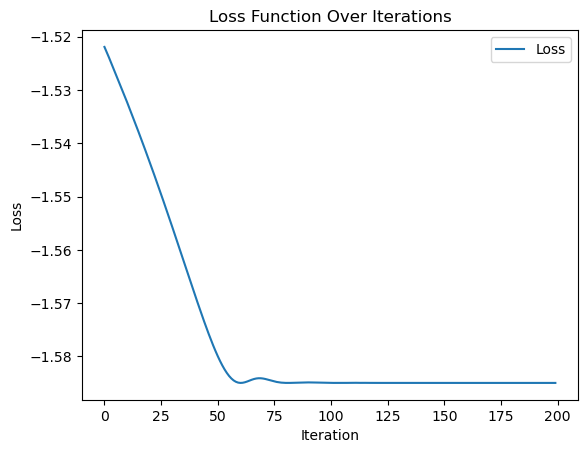

In [5]:

# Definimos las variables  x_1 y x_2 como un tensor de TensorFlow (variable)
x = tf.Variable([2.0,4.0])

# Definimos el optimizer (En este caso, Adam optimizer)
optimizer = tf.optimizers.Adam(learning_rate=0.05)  


# Definimos la función objetivo
def loss_fn():
    resultado = ((x[0]**2/(x[0]**2+x[0]+x[1]))*tf.math.log((x[0]**2/(x[0]**2+x[0]+x[1])))/tf.math.log(tf.constant(2.0))) + ((x[0]/(x[0]**2+x[0]+x[1]))*tf.math.log((x[0]/(x[0]**2+x[0]+x[1])))/tf.math.log(tf.constant(2.0))) +((x[1]/(x[0]**2+x[0]+x[1]))*tf.math.log((x[1]/(x[0]**2+x[0]+x[1])))/tf.math.log(tf.constant(2.0)))
    return resultado

# Store the loss values for plotting
loss_values = []

# Run optimization for a few iterations
num_iterations = 200
for i in range(num_iterations):
    with tf.GradientTape() as tape:
        # Compute the loss
        loss = loss_fn()
        
        # Calculamos los gradientes de la función objetivo respecto de x_1 y x_2. 
        gradients = tape.gradient(loss, [x]) 
                                            
        # Aplicamos los gradients para actualizar x_1 y x_2.
        optimizer.apply_gradients(zip(gradients, [x]))
    
        
        # Guardamos el valor de la función de pérdida en la iteración actual para graficarla posteriormente
        loss_values.append(loss.numpy())

        # Print the current values of x, y, and the loss
        if i % 10 == 0:
            print(f"Iteration {i}: x = {x[0].numpy()}, y = {x[1].numpy()}, loss = {loss.numpy()}")



# Plot the loss function values over iterations
plt.plot(range(num_iterations), loss_values, label="Loss")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Function Over Iterations')
plt.legend()
plt.show()

# Problem 2:

Given a dataset $ D = \{(x_i, y_i)\}_{i=1}^{N} $, where $ x_i $ are the input data points and $ y_i $ are the corresponding observed outputs, you are tasked with fitting the following nonlinear function:

$$
f(x; \beta) = \beta_1 \cdot \sin(\beta_2 \cdot x) + \beta_3 \cdot e^{-\beta_4 \cdot x}
$$

where $ \beta = [\beta_1, \beta_2, \beta_3, \beta_4] $ are the parameters to be optimized.

### Objective:

Minimize the Mean Squared Error (MSE) between the predicted values $ f(x_i; \beta) $ and the observed data $ y_i $, defined as:

$$
\text{MSE}(\beta) = \frac{1}{N} \sum_{i=1}^{N} \left( f(x_i; \beta) - y_i \right)^2
$$

### Instructions:

1. **Load the Data**: You are provided with a dataset containing the values of $ x_i $ and $ y_i $.

2. **Implement the Loss Function** and **Optimize the Parameters**:  Verify that the optimization reaches an MSE value lower than 0.3 within 1000 iterations.

*NOTE: apart from using the plot of loss vs. iterations, you can plot the real data and estimated data in a "Y vs. X" scatterplot to verify if the result of the optimizaton is correct.*

   Embed the code into the following function for testing purposes.
   ```python 
   # Test function
   def test_fcn_problem_2a(X,Y,iter, betas = Null)
    # X and Y are the input data.
    # iter is the number of iterations for the optimization
    # betas are the initial values of the optimization variables --> If Null, initiate randomly.

    # Returns the optimum betas and the loss
    return beta_opt, loss
   ```

3. Implement a **stochastic version of the gradient descent** algorithm to optimize the parameters using mini-batches.
   
   Embed the code into the following function for testing purposes.
   ```python 
   # Test function
   def test_fcn_problem_2b(X,Y,iter, batch_size, betas = Null)
    # X and Y are the input data.
    # iter is the number of iterations for the optimization
    # batch_size is the size of the batches for the Stochastic optimization
    # betas are the initial values of the optimization variables --> If Null, initiate randomly.

    # Returns the optimum betas and the loss
    return beta_opt, loss
   ```

Iteration 0: beta_1 = -1.7281112670898438, beta_2 = -1.4318861961364746, beta_3 = 3.688096761703491,beta_4 = 0.6418871879577637, loss = 0.7226260900497437
Iteration 10: beta_1 = -1.9536643028259277, beta_2 = -1.477568507194519, beta_3 = 3.434812307357788,beta_4 = 0.6418887376785278, loss = 0.20529967546463013
Iteration 20: beta_1 = -1.964984655380249, beta_2 = -1.4791951179504395, beta_3 = 3.404977321624756,beta_4 = 0.6306848526000977, loss = 0.2127615362405777
Iteration 30: beta_1 = -1.9640192985534668, beta_2 = -1.471002221107483, beta_3 = 3.405848503112793,beta_4 = 0.6218128204345703, loss = 0.24011284112930298
Iteration 40: beta_1 = -1.966294527053833, beta_2 = -1.4695045948028564, beta_3 = 3.4029414653778076,beta_4 = 0.6198406219482422, loss = 0.23624826967716217
Iteration 50: beta_1 = -1.9669290781021118, beta_2 = -1.4721436500549316, beta_3 = 3.400487184524536,beta_4 = 0.6223395466804504, loss = 0.22827216982841492
Iteration 60: beta_1 = -1.9663949012756348, beta_2 = -1.47223901

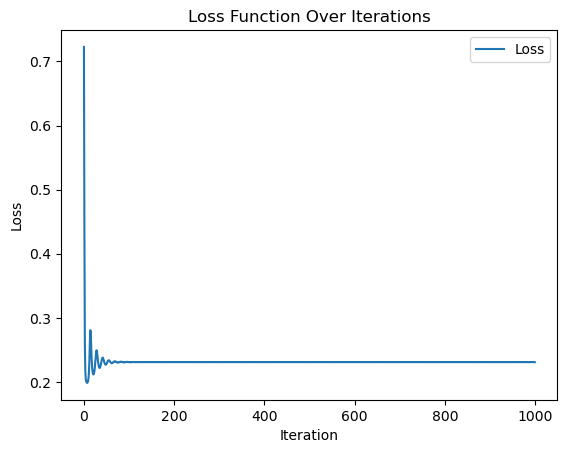

In [400]:
import numpy as np
import tensorflow as tf

# Cargamos los datos relativos a la variable dependiente (y) e independiente (x) 
df = pd.read_csv('Problem_2_Data.csv')
X = df['x'].to_numpy()
y = df['y'].to_numpy()

# Conversión a tensores de Tensor Flow
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

# Inicializamos los coeficientes beta. Importante definirlo como una variable de Tensor Flow, ya que son los parametros a optimizar.
# beta = tf.Variable(tf.random.normal([4, 1], dtype=tf.float32)*0.01)
beta=tf.Variable([-1.57,-1.59,3.53,0.80])

# Definimos el optimizer (en este caso, usamos RMSprop)
optimizer = tf.optimizers.RMSprop(learning_rate=0.05)

# Otras opciones de optimizador:
# SGD:
# optimizer = tf.optimizers.SGD(learning_rate=0.05)
# Nesterov:
# optimizer = tf.optimizers.SGD(learning_rate=0.05, momentum=0.9, nesterov=True)
# ADAM:
# optimizer = tf.optimizers.Adam(learning_rate=0.05)
# Adagrad:
# optimizer = tf.optimizers.Adagrad(learning_rate=0.05)

# Defimos la función de pérdida
def loss_fn():

    #Calculamos el valor actual de y que predice nuestro modelo (y_pred), el cual es un tensor de TensorFlow.
    y_pred = beta[0]*tf.sin(beta[1]*X_tf)+beta[2]*tf.exp(-beta[3]*X_tf)

    #Hacemos un reshape de los tensores
    y_pred = tf.reshape(y_pred, (y_pred.shape[0],1))
    y = tf.reshape(y_tf, (y_pred.shape[0],y_pred.shape[1]))


    #Como función de pérdida, usamos la norma L2.
    loss = (y_pred-y)**2
    
    return tf.math.reduce_mean(loss)

# Lista para almacenar los valores de la función de pérdida a lo largo de las diferentes iteraciones
loss_values = []

# Run optimization for a few iterations
num_iterations = 1000
for i in range(num_iterations):
    with tf.GradientTape() as tape:
        # Calculamos la función de pérdida.
        loss = loss_fn()
        
        # Calculamos los gradientes de la funcion de perdida respecto de los parámetros beta.
        gradients = tape.gradient(loss, [beta]) 
    
        # Aplicamos los gradientes para actualizar el valor de los parámetros beta.
        optimizer.apply_gradients(zip(gradients, [beta]))
        
        # Store the loss values for the graph
        loss_values.append(loss.numpy())

        # Print the current values of x, y, and the loss
        if i % 10 == 0:
            print(f"Iteration {i}: beta_1 = {beta[0].numpy()}, beta_2 = {beta[1].numpy()}, beta_3 = {beta[2].numpy()},beta_4 = {beta[3].numpy()}, loss = {loss.numpy()}")


print(f"Final model coefficients (beta): {beta.numpy().flatten()}")


# Plot the loss function values over iterations
plt.plot(range(num_iterations), loss_values, label="Loss")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Function Over Iterations')
plt.legend()
plt.show()

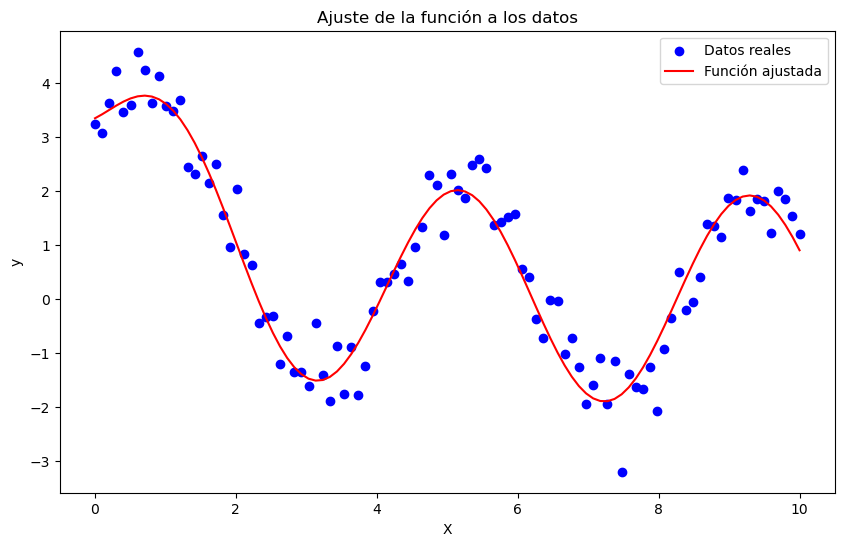

In [402]:
plt.figure(figsize=(10, 6))

# Graficar los puntos del dataset (X, y)
plt.scatter(X, y, color='blue', label='Datos reales')

# Graficar la función ajustada con los parámetros optimizados
X_fit = np.linspace(min(X), max(X), 100)  # Generar valores de X para el gráfico de la función ajustada
y_fit = beta[0].numpy() * np.sin(beta[1].numpy() * X_fit) + beta[2].numpy() * np.exp(-beta[3].numpy() * X_fit)  # Valores de y con los betas optimizados

plt.plot(X_fit, y_fit, color='red', label='Función ajustada')

# Etiquetas y título
plt.xlabel('X')
plt.ylabel('y')
plt.title('Ajuste de la función a los datos')
plt.legend()
plt.show()

Epoch 0, Loss: 5.0117
Epoch 10, Loss: 0.2123
Epoch 20, Loss: 0.2172
Epoch 30, Loss: 0.2299
Epoch 40, Loss: 0.2055
Epoch 50, Loss: 0.1864
Epoch 60, Loss: 0.2031
Epoch 70, Loss: 0.2382
Epoch 80, Loss: 0.2386
Epoch 90, Loss: 0.2096
Epoch 100, Loss: 0.1668
Epoch 110, Loss: 0.2451
Epoch 120, Loss: 0.1353
Epoch 130, Loss: 0.1670
Epoch 140, Loss: 0.3074
Epoch 150, Loss: 0.2758
Epoch 160, Loss: 0.1335
Epoch 170, Loss: 0.2077
Epoch 180, Loss: 0.2011
Epoch 190, Loss: 0.1603
Epoch 200, Loss: 0.2311
Epoch 210, Loss: 0.1983
Epoch 220, Loss: 0.3192
Epoch 230, Loss: 0.2011
Epoch 240, Loss: 0.1936
Epoch 250, Loss: 0.2550
Epoch 260, Loss: 0.1811
Epoch 270, Loss: 0.1852
Epoch 280, Loss: 0.2812
Epoch 290, Loss: 0.2019
Epoch 300, Loss: 0.3083
Epoch 310, Loss: 0.1987
Epoch 320, Loss: 0.2834
Epoch 330, Loss: 0.1796
Epoch 340, Loss: 0.2444
Epoch 350, Loss: 0.1686
Epoch 360, Loss: 0.2791
Epoch 370, Loss: 0.2107
Epoch 380, Loss: 0.1512
Epoch 390, Loss: 0.1578
Epoch 400, Loss: 0.2132
Epoch 410, Loss: 0.0818
Epo

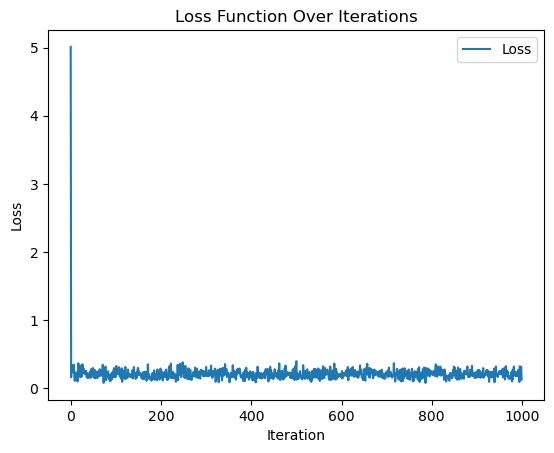

In [394]:
# Definimos el tamaño del lote para el método SGD
batch_size = 20

#Creamos dos variables, que almacenan información sobre el número de muestras (n_samples) y la dimensionalidad de ellas (n_features).
n_samples = X.shape[0]
n_features = 1

# Inicializamos los parámetros del modelo (Coeficientes beta)
beta_SGD = tf.Variable([-2.0,-1.0,3.0,0.0],dtype=tf.float32)


  
# Función de pérdida 
def loss_fn(X, y, beta):
   
    y_pred = beta[0]*tf.sin(beta[1]*X)+beta[2]*tf.exp(-beta[3]*X)
    
    loss = (y_pred-y)**2
    
    return tf.math.reduce_mean(loss)
    

# Inicializamos la lista para almacenar la función de pérdida. 
loss_values = []
  
# Bucle de entrenamiento con mini-lote de descenso de gradiente
num_epochs = 1000
num_batches = X.shape[0] // batch_size

# Definimos el optimizador (Stochast Gradient Descent)
optimizer = tf.optimizers.SGD(learning_rate=0.005)

# Una época es un ciclo completo de entrenamiento sobre todo el conjunto de datos. 
for epoch in range(num_epochs):
    # Generamos los índices aleatorios que barajan las muestras de datos de entrenamiento. La función np.random.permutation crea una 
    # permutación aleatoria de los índices de las muestras para asegurarse de que el orden de las muestras cambie en cada época.
    indices = np.random.permutation(len(X))

    # Estas líneas reordenan las muestras de los datos (X_tf y y_tf) usando los índices aleatorios generados previamente. Así, 
    # en cada época, los datos de entrada (X_tf) y las etiquetas (y_tf) se barajan para una mejor generalización.
    X_tf = tf.gather(X_tf, indices)
    y_tf = tf.gather(y_tf, indices)
    
    # Este segundo bucle for, se encarga de dividir los datos en mini-lotes (grupos más pequeños) para cada paso de entrenamiento dentro 
    # de una época. El tamaño del mini-lote es 20 (batch_size = 20), lo que significa que en cada iteración del bucle se seleccionan 20 
    # muestras para actualizar los parámetros del modelo.
    for i in range(0, X.shape[0], batch_size):

        # Estas dos líneas seleccionan los mini-lotes actuales de datos de entrada (X_batch) y etiquetas (y_batch) del conjunto de datos 
        # barajado.
        X_batch = X_tf[i:i+batch_size]
        y_batch = y_tf[i:i+batch_size]
        
        # Entrenamiento (usando mini-batches)
        with tf.GradientTape() as tape:
            loss = loss_fn(X_batch, y_batch, beta_SGD)
        gradients = tape.gradient(loss, [beta_SGD])
        optimizer.apply_gradients(zip(gradients, [beta_SGD]))
        
    loss_values.append(loss.numpy())
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy():.4f}")

# Print final model coefficients (beta)
print(f"Final model coefficients (beta): {beta_SGD.numpy().flatten()}")

plt.figure()
# Plot the loss function values over iterations
plt.plot(range(num_epochs), loss_values, label="Loss")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Function Over Iterations')
plt.legend()
plt.show()

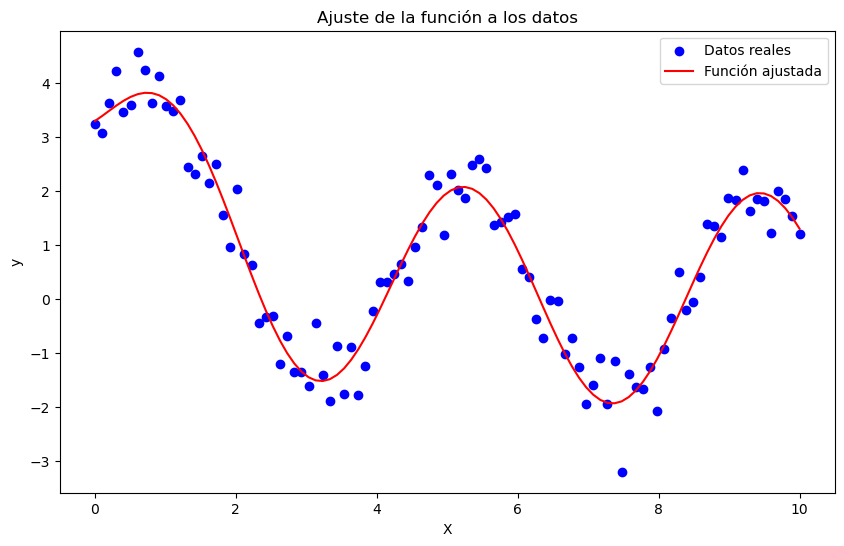

In [396]:
plt.figure(figsize=(10, 6))

# Graficar los puntos del dataset (X, y)
plt.scatter(X, y, color='blue', label='Datos reales')

# Graficar la función ajustada con los parámetros optimizados
X_fit = np.linspace(min(X), max(X), 100)  # Generar valores de X para el gráfico de la función ajustada
y_fit = beta_SGD[0].numpy() * np.sin(beta_SGD[1].numpy() * X_fit) + beta_SGD[2].numpy() * np.exp(-beta_SGD[3].numpy() * X_fit)  # Valores de y con los betas optimizados

plt.plot(X_fit, y_fit, color='red', label='Función ajustada')

# Etiquetas y título
plt.xlabel('X')
plt.ylabel('y')
plt.title('Ajuste de la función a los datos')
plt.legend()
plt.show()

# Exercise 3: 

Given a dataset with three input variables $X_i$ and one output variable $Y$, the objective is to fit a linear regression model for estimating $Y$ as a function of $X_i$:
$$
y_i =\beta_0 + \beta_1 \cdot x_{i1} + \beta_2 \cdot x_{i2} + \beta_3 \cdot x_{i3}  + \epsilon_i
$$
However, instead of minimizing the MSE, we will maximize the log-likelihood of the data assuming a Gaussian noise model. 

### Instructions:

1. Load the Data: *Problem_3_Data_ok.csv*

2. Program the prediction equation:
$$
\hat{y}_i = \beta_0 + \beta_1 \cdot x_{i1} + \beta_2 \cdot x_{i2} + \beta_3 \cdot x_{i3}
$$

3. Program the Probability density Function  $P(y_i | \hat{y}_i, \sigma) $. This represents the probability of observing the output $ y_i $, given the inputs and parameters. It follows a normal distribution. The probability $ P(y_i | \hat{y}_i, \sigma) $ is:

   $$
   P(y_i | \hat{y}_i, \sigma) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp \left( - \frac{(y_i - \hat{y}_i)^2}{2 \sigma^2} \right)
   $$

   where:
   - $ \hat{y}_i $ is the predicted output using the current model parameters,
   - $ \sigma^2 $ is the variance of the Gaussian noise.
  
   In python:
   ```python
   def norm_prob(y,yest,sigma)

      return prob
   ```

4. Define the loss function as the Log-Likelihood Loss Function. For all observed data points, the log-likelihood of the model is the sum of the log of the probability densities: 
   $$
   L(\beta, \sigma) = \sum_{i=1}^N \log(P(y_i | \hat{y}_i, \sigma) )
   $$

   where:
   - $ N $ is the number of observed data points.
   - $ y_i $ is the actual observed output,
   - $ \hat{y}_i $ is the predicted output from the model,
   - $ \sigma^2 $ is the variance of the residuals (the error between the predicted and actual outputs).


5. **Optimize the Log-Likelihood**: You'll need to estimate both $ \beta_0 $ to $ \beta_3 $ and **$\sigma $**. *(NOTE: Yes, "sigma" is also a variable to be optimized. You can define a vector of tf.variable with 5 values and use the last one as the "sigma")*


NOTE:

After fitting an standard OLS model to the data, these are the results. 

The log-likelihood for the fitted parameters is shown in the table. It can be used to test the loss function of step 4.

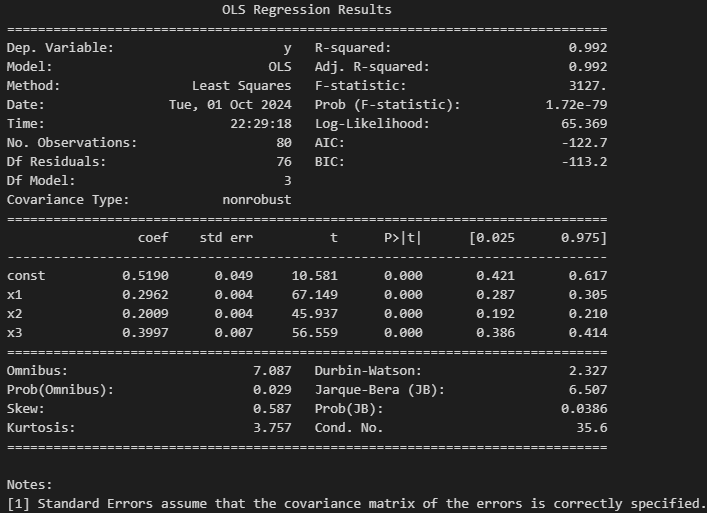



Iteration 0: beta_0 = [0.50699985], beta_1 = [0.29300007], beta_2 = [0.20699994],beta_3 = [0.40699995], sigma^2 = [0.99300003], loss = 73.975341796875
Iteration 10: beta_0 = [0.50616974], beta_1 = [0.2991175], beta_2 = [0.20002978],beta_3 = [0.40205455], sigma^2 = [0.92279464], loss = 71.10277557373047
Iteration 20: beta_0 = [0.5081402], beta_1 = [0.29738656], beta_2 = [0.20314552],beta_3 = [0.3996953], sigma^2 = [0.85163015], loss = 67.96804809570312
Iteration 30: beta_0 = [0.51071924], beta_1 = [0.29586366], beta_2 = [0.20040824],beta_3 = [0.40098542], sigma^2 = [0.77872765], loss = 64.47254943847656
Iteration 40: beta_0 = [0.51363015], beta_1 = [0.2963858], beta_2 = [0.2014855],beta_3 = [0.4003362], sigma^2 = [0.7033672], loss = 60.516197204589844
Iteration 50: beta_0 = [0.5160055], beta_1 = [0.29680565], beta_2 = [0.20109531],beta_3 = [0.4001127], sigma^2 = [0.6248318], loss = 55.93479537963867
Iteration 60: beta_0 = [0.5178303], beta_1 = [0.29616913], beta_2 = [0.20122147],beta_3 

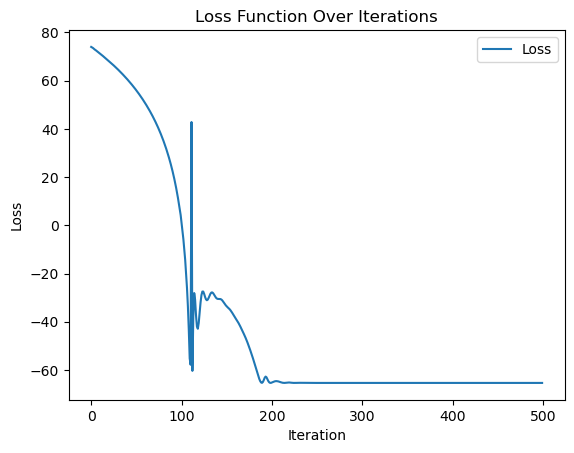

In [369]:
import tensorflow as tf
import numpy as np
from math import sqrt, pi, exp

# Cargamos los datos
df = pd.read_csv('Problem_3_Data_ok.csv')
X = df.iloc[:, :3].to_numpy()
y = df['Y'].to_numpy()

# Convertimos el vector de variables independientes y la variable dependiente en un Tensor de TensorFlow.
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

# Inicialicamos los parámetros del modelo (beta coefficients)
beta = tf.Variable([0.5, 0.3, 0.2, 0.4, 1.0], dtype=tf.float32)
beta = tf.Variable(tf.reshape(beta, [5, 1])) 

# Definimos el optimizador. En este caso, usamos el Adam.
# optimizer = tf.optimizers.RMSprop(learning_rate=0.2/0.18)  FUNCIONA
optimizer = tf.optimizers.Adam(learning_rate=0.007)  

#Función para calcular la función de densidad de probabilidad.
def norm_prob(y,yest,sigma_2):
    
    # Usamos las funciones de TensorFlow en lugar de las funciones estándar
    coeficiente = 1 / tf.sqrt(2 * pi * sigma_2)
    exponencial = tf.exp(-((y - yest)**2) / (2 * sigma_2))
    
    # Calculamos prob usando las operaciones de TensorFlow
    prob = coeficiente * exponencial

    return prob

# Definimos la función objetivo. En este caso, queremos maximizar la verosimilitud, luego minimizamos el logaritmo de la menos verosimilitud.
def loss_fn():
    
    #Calculamos el valor de y_pred.
    y_pred = beta[0]+tf.matmul(X_tf, beta[1:-1])
    
    #Reshape de los tensores. 
    y = tf.reshape(y_tf, (y_pred.shape[0],y_pred.shape[1]))
    
    return - tf.reduce_sum (tf.math.log(norm_prob(y, y_pred, beta[-1])+1e-5))
    
    
# Store the loss values for plotting
loss_values = []

# Run optimization for a few iterations
num_iterations = 500
for i in range(num_iterations):
    with tf.GradientTape() as tape:
        # Compute the loss
        loss = loss_fn()
        
        # Compute gradients of x and y with respect to the loss
        gradients = tape.gradient(loss, [beta]) 
        # Apply gradients to update x.
        optimizer.apply_gradients(zip(gradients, [beta]))
        
        # Store the loss values for the graph
        loss_values.append(loss.numpy())

        # Print the current values of x, y, and the loss
        if i % 10 == 0:
            print(f"Iteration {i}: beta_0 = {beta[0].numpy()}, beta_1 = {beta[1].numpy()}, beta_2 = {beta[2].numpy()},beta_3 = {beta[3].numpy()}, sigma^2 = {beta[4].numpy()}, loss = {loss.numpy()}")

#tf_trajectory = np.array(tf_trajectory)
print(f"Final model coefficients (beta): {beta.numpy().flatten()}")


# Plot the loss function values over iterations
plt.plot(range(num_iterations), loss_values, label="Loss")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Function Over Iterations')
plt.legend()
plt.show()

In [252]:
#==========================================================================================================================================
#                                                       StatsModels 
#==========================================================================================================================================


#fit linear regression model with statsmodels and show results
import statsmodels.api as sm
ols_model = sm.OLS(y, sm.add_constant(X))
result = ols_model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     3127.
Date:                Sun, 13 Oct 2024   Prob (F-statistic):           1.72e-79
Time:                        12:39:27   Log-Likelihood:                 65.369
No. Observations:                  80   AIC:                            -122.7
Df Residuals:                      76   BIC:                            -113.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5190      0.049     10.581      0.0